In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
uploaded = files.upload()
df = pd.read_excel(list(uploaded.keys())[0])

Saving Data_Analytics_Intern_Project_Dataset_50K.xlsx to Data_Analytics_Intern_Project_Dataset_50K (1).xlsx


In [ ]:
df.head()

,Record_ID,Account_ID,Client_ID,Business_Date,Region,Country,Department,Process_Name,Risk_Level,SLA_Days,Actual_Days,Amount,Exposure,Loss,Team_Lead,Manager,Delay_Days,SLA_Breach
0,1,221958,28175,2022-01-01 00:00:00,East,India,IT,KYC,High,3,3,199387.85,273587.79,2414.52,TL_B,Manager_1,0,No
1,2,771155,58887,2022-01-01 01:00:00,North,India,Risk,Reconciliation,Low,6,6,212029.71,49734.40,22045.34,TL_B,Manager_1,5,No
2,3,231932,61671,2022-01-01 02:00:00,North,India,Compliance,Reporting,Medium,9,14,96602.06,84088.72,19381.36,TL_C,Manager_1,0,Yes
3,4,465838,10961,2022-01-01 03:00:00,South,India,IT,Payments,Low,8,7,134358.07,126295.32,44595.37,TL_C,Manager_3,4,No
4,5,359178,79285,2022-01-01 04:00:00,North,India,IT,Reconciliation,Low,3,7,310430.73,128040.83,46584.89,TL_C,Manager_3,5,Yes


In [ ]:
print("Shape of the Dataset:",df.shape)

Shape of the Dataset: (50000, 18)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Record_ID      50000 non-null  int64         
 1   Account_ID     50000 non-null  int64         
 2   Client_ID      50000 non-null  int64         
 3   Business_Date  50000 non-null  datetime64[ns]
 4   Region         50000 non-null  object        
 5   Country        50000 non-null  object        
 6   Department     50000 non-null  object        
 7   Process_Name   50000 non-null  object        
 8   Risk_Level     50000 non-null  object        
 9   SLA_Days       50000 non-null  int64         
 10  Actual_Days    50000 non-null  int64         
 11  Amount         50000 non-null  float64       
 12  Exposure       50000 non-null  float64       
 13  Loss           50000 non-null  float64       
 14  Team_Lead      50000 non-null  object        
 15  Manager        5000

In [ ]:
print("Missing Values:\n", df.isnull().sum())

Missing Values:
 Record_ID        0
Account_ID       0
Client_ID        0
Business_Date    0
Region           0
Country          0
Department       0
Process_Name     0
Risk_Level       0
SLA_Days         0
Actual_Days      0
Amount           0
Exposure         0
Loss             0
Team_Lead        0
Manager          0
Delay_Days       0
SLA_Breach       0
dtype: int64


In [ ]:
print("Duplicate values:", df.duplicated().sum())

Duplicate values: 0


In [ ]:
df.describe()

,Record_ID,Account_ID,Client_ID,Business_Date,SLA_Days,Actual_Days,Amount,Exposure,Loss,Delay_Days
count,50000.000000,50000.000000,50000.000000,50000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,25000.500000,550722.363700,54944.174260,2024-11-07 15:30:00,4.999140,7.499960,254602.662851,152316.341667,24951.761798,3.457420
min,1.000000,100005.000000,10001.000000,2022-01-01 00:00:00,1.000000,1.000000,10001.090000,5011.790000,1.560000,0.000000
25%,12500.750000,324493.250000,32500.000000,2023-06-05 19:45:00,3.000000,4.000000,131831.652500,78674.710000,12531.515000,0.000000
50%,25000.500000,552307.500000,55039.500000,2024-11-07 15:30:00,5.000000,7.000000,253882.285000,152442.835000,24942.870000,2.000000
75%,37500.250000,776491.750000,77149.000000,2026-04-12 11:15:00,7.000000,11.000000,376944.627500,226145.357500,37380.680000,6.000000
max,50000.000000,999997.000000,99997.000000,2027-09-15 07:00:00,9.000000,14.000000,499997.360000,299994.770000,49999.350000,13.000000
std,14433.901067,260766.036275,25931.250558,NaN,2.581843,4.032662,141195.659638,85247.005743,14420.095647,3.610774


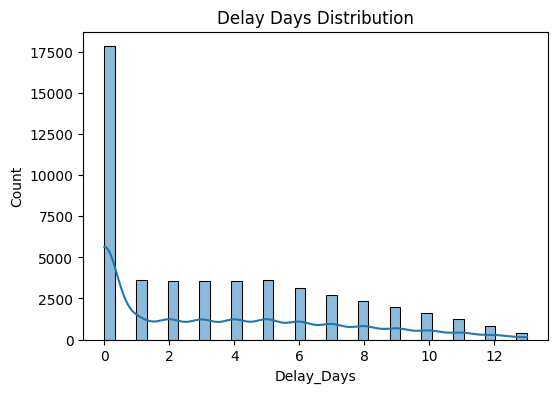

In [ ]:
#Delay Distribution
plt.figure(figsize=(6,4))
sns.histplot(df["Delay_Days"], kde=True)
plt.title("Delay Days Distribution")
plt.show()

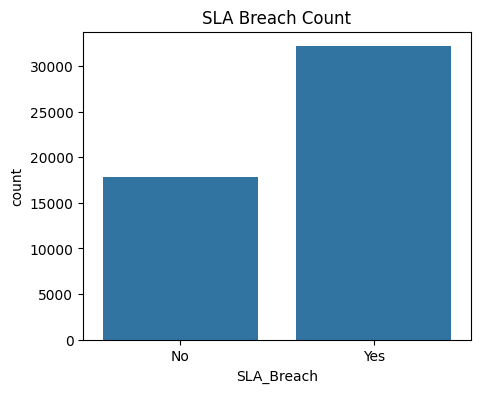

In [ ]:
#SLA Breach count
plt.figure(figsize=(5,4))
sns.countplot(x=df["SLA_Breach"])
plt.title("SLA Breach Count")
plt.show()

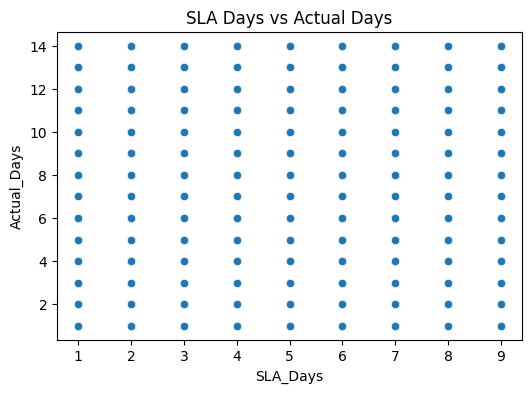

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(x="SLA_Days", y="Actual_Days", data=df)
plt.title("SLA Days vs Actual Days")
plt.show()

/tmp/ipython-input-3315437303.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bucket_data = df.groupby("Exposure_Bucket")["Loss"].mean()


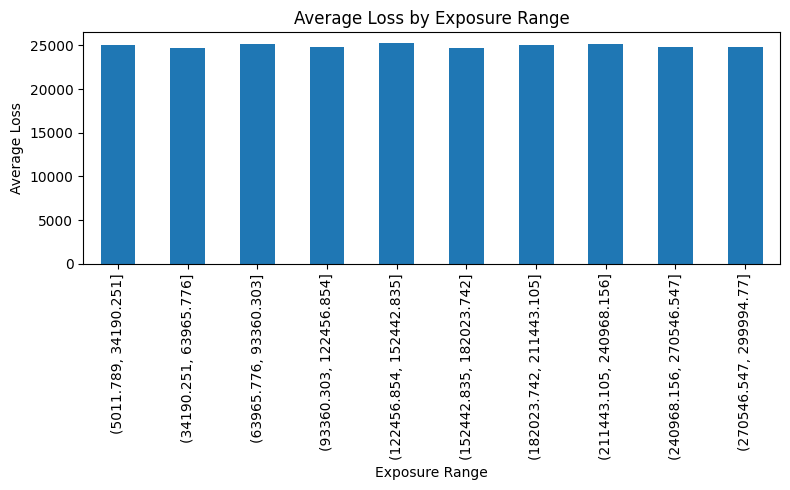

In [ ]:
# Create exposure buckets
df["Exposure_Bucket"] = pd.qcut(df["Exposure"], 10)

# Calculate average loss per bucket
bucket_data = df.groupby("Exposure_Bucket")["Loss"].mean()
plt.figure(figsize=(8,5))
bucket_data.plot(kind="bar")
plt.title("Average Loss by Exposure Range")
plt.xlabel("Exposure Range")
plt.ylabel("Average Loss")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

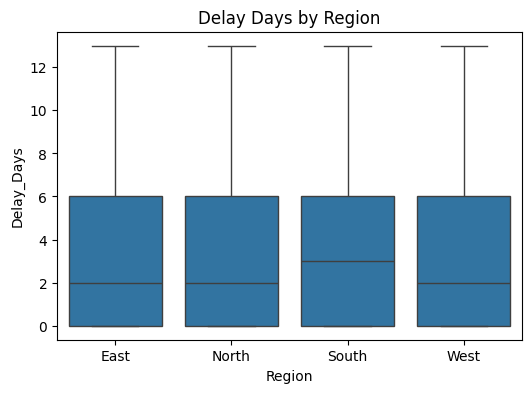

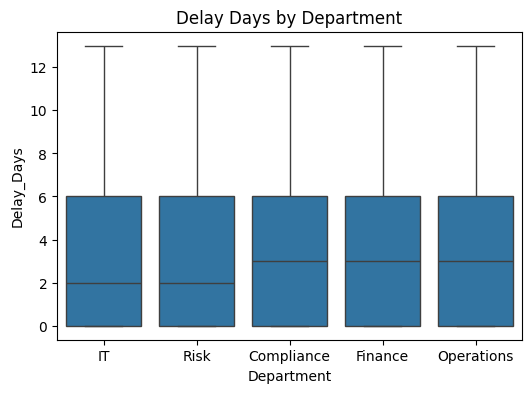

In [ ]:
# Delay Days by Region
plt.figure(figsize=(6,4))
sns.boxplot(x="Region", y="Delay_Days", data=df)
plt.title("Delay Days by Region")
plt.show()

# Delay Days by Department
plt.figure(figsize=(6,4))
sns.boxplot(x="Department", y="Delay_Days", data=df)
plt.title("Delay Days by Department")
plt.show()

In [ ]:
# Delivery status
df["Delivery_Status"] = df["Delay_Days"].apply(
    lambda x: "Early" if x < 0 else "On Time" if x == 0 else "Late"
)
df["Delivery_Status"].value_counts()


,count
Delivery_Status,
Late,32170
On Time,17830
